# **Bank Term Deposit Subscription Prediction using Logistic Regression**



## Business Problem

A bank runs marketing campaigns (phone calls, emails, messages) to sell **term deposits**
to clients. Contacting every client is expensive and time-consuming, and historically only
a small fraction of contacted clients actually subscribe.

**Goal:** Build a classification model that predicts whether a client will subscribe to a
term deposit (`y = yes/no`) based on the given attributes.

**Model requested:** Logistic Regression

### Workflow
1. Load & understand the data
2. Data cleaning & preprocessing
3. Exploratory Data Analysis (EDA)
4. Feature engineering & encoding
5. Train/test split and scaling
6. Train Logistic Regression model
7. Evaluate performance (accuracy, precision, recall, F1, ROC-AUC, confusion matrix)



## 1. Load & understand the data

In [18]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score,
    roc_curve, precision_recall_curve
)

sns.set_style("whitegrid")  # Makes Seaborn plots look cleaner with a white background and grid lines
pd.set_option("display.max_columns", None) #Tells Pandas to display all columns of a DataFrame instead of hiding some.
%matplotlib inline


About Dataset

| Column | Description |
|---|---|
| age | Client's age |
| job | Type of job |
| marital | Marital status |
| education | Highest education level |
| default | Has credit in default? |
| housing | Has housing loan? |
| loan | Has personal loan? |
| contact | Contact communication type |
| month | Last contact month |
| day_of_week | Last contact day of week |
| duration | Last contact duration (seconds) |
| campaign | # contacts during this campaign for this client |
| pdays | Days since client was last contacted from a previous campaign (999 = not previously contacted) |
| previous | # contacts performed before this campaign for this client |
| poutcome | Outcome of the previous marketing campaign |
| emp.var.rate | Employment variation rate (quarterly) |
| cons.price.idx | Consumer price index (monthly) |
| cons.conf.idx | Consumer confidence index (monthly) |
| euribor3m | Euribor 3 month rate (daily) |
| nr.employed | Number of employees (quarterly) |
| y | Target: has the client subscribed to a term deposit? |


In [19]:
df = pd.read_csv("bank-additional.csv")
print("Shape:", df.shape)
df.head()

Shape: (4119, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,30,blue-collar,married,basic.9y,no,yes,no,cellular,may,fri,487,2,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no
1,39,services,single,high.school,no,no,no,telephone,may,fri,346,4,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
2,25,services,married,high.school,no,yes,no,telephone,jun,wed,227,1,999,0,nonexistent,1.4,94.465,-41.8,4.962,5228.1,no
3,38,services,married,basic.9y,no,unknown,unknown,telephone,jun,fri,17,3,999,0,nonexistent,1.4,94.465,-41.8,4.959,5228.1,no
4,47,admin.,married,university.degree,no,yes,no,cellular,nov,mon,58,1,999,0,nonexistent,-0.1,93.200,-42.0,4.191,5195.8,no


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4119 entries, 0 to 4118
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             4119 non-null   int64  
 1   job             4119 non-null   object 
 2   marital         4119 non-null   object 
 3   education       4119 non-null   object 
 4   default         4119 non-null   object 
 5   housing         4119 non-null   object 
 6   loan            4119 non-null   object 
 7   contact         4119 non-null   object 
 8   month           4119 non-null   object 
 9   day_of_week     4119 non-null   object 
 10  duration        4119 non-null   int64  
 11  campaign        4119 non-null   int64  
 12  pdays           4119 non-null   int64  
 13  previous        4119 non-null   int64  
 14  poutcome        4119 non-null   object 
 15  emp.var.rate    4119 non-null   float64
 16  cons.price.idx  4119 non-null   float64
 17  cons.conf.idx   4119 non-null   f

In [21]:
df.describe(include="all").T #.T stands for Transpose.(Transpose = Swap rows and columns)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,4119.0,NaN,NaN,NaN,40.11362,10.313362,18.0,32.0,38.0,47.0,88.0
job,4119,12,admin.,1012,NaN,NaN,NaN,NaN,NaN,NaN,NaN
marital,4119,4,married,2509,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education,4119,8,university.degree,1264,NaN,NaN,NaN,NaN,NaN,NaN,NaN
default,4119,3,no,3315,NaN,NaN,NaN,NaN,NaN,NaN,NaN
housing,4119,3,yes,2175,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan,4119,3,no,3349,NaN,NaN,NaN,NaN,NaN,NaN,NaN
contact,4119,2,cellular,2652,NaN,NaN,NaN,NaN,NaN,NaN,NaN
month,4119,10,may,1378,NaN,NaN,NaN,NaN,NaN,NaN,NaN
day_of_week,4119,5,thu,860,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Data Cleaning & Preprocessing

#### 2.1 Check for missing/duplicate values

In [22]:
df.isnull().sum().sum()

np.int64(0)

In [23]:
# Drop exact duplicate rows if any
before = df.shape[0]
df = df.drop_duplicates()
print(f"Dropped {before - df.shape[0]} duplicate rows")

Dropped 0 duplicate rows


#### 2.1 Dropping **Duration** column

The duration column records the length of the phone call, which is only known after the call has taken place. Since our goal is to predict whether a customer will subscribe before making the call, using duration would introduce data leakage (using future information). Therefore, it is removed to build a realistic and practical model for pre-call customer targeting, even though this may slightly reduce prediction accuracy.

In [24]:
df = df.drop(columns=["duration"])
df.shape


(4119, 20)

#### 2.3 The pdays column

In this dataset, 999 is not the actual number of days since the last contact. It is a special code meaning the customer was never contacted before. To avoid confusing the model, a new binary feature was_previously_contacted is created (1 = previously contacted, 0 = never contacted). This allows the model to interpret the information correctly.

In [25]:
df["was_previously_contacted"] = (df["pdays"] != 999).astype(int)
df[["pdays", "previous", "poutcome", "was_previously_contacted"]].head()

,pdays,previous,poutcome,was_previously_contacted
0,999,0,nonexistent,0
1,999,0,nonexistent,0
2,999,0,nonexistent,0
3,999,0,nonexistent,0
4,999,0,nonexistent,0


## 3. Exploratory Data Analysis (EDA

#### 3.1 Target variable distribution — class imbalance

y
no     3668
yes     451
Name: count, dtype: int64
y
no     89.05
yes    10.95
Name: proportion, dtype: float64


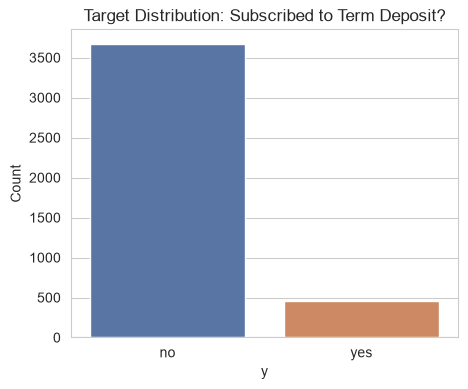

In [26]:
target_counts = df["y"].value_counts()
target_pct = df["y"].value_counts(normalize=True) * 100
print(target_counts)
print(target_pct.round(2))

plt.figure(figsize=(5,4))
sns.countplot(x="y", data=df, palette=["#4C72B0", "#DD8452"])
plt.title("Target Distribution: Subscribed to Term Deposit?")
plt.xlabel("y")
plt.ylabel("Count")
plt.show()

**Observation:** The dataset is **imbalanced** — only about 11% of clients subscribed
(`yes`). This matters for both model training and evaluation: plain accuracy can be
misleading (predicting "no" for everyone gives ~89% accuracy), so we will rely on
precision, recall, F1, and ROC-AUC, and use `class_weight="balanced"` in Logistic
Regression.

#### 3.2 Numeric feature distributions¶


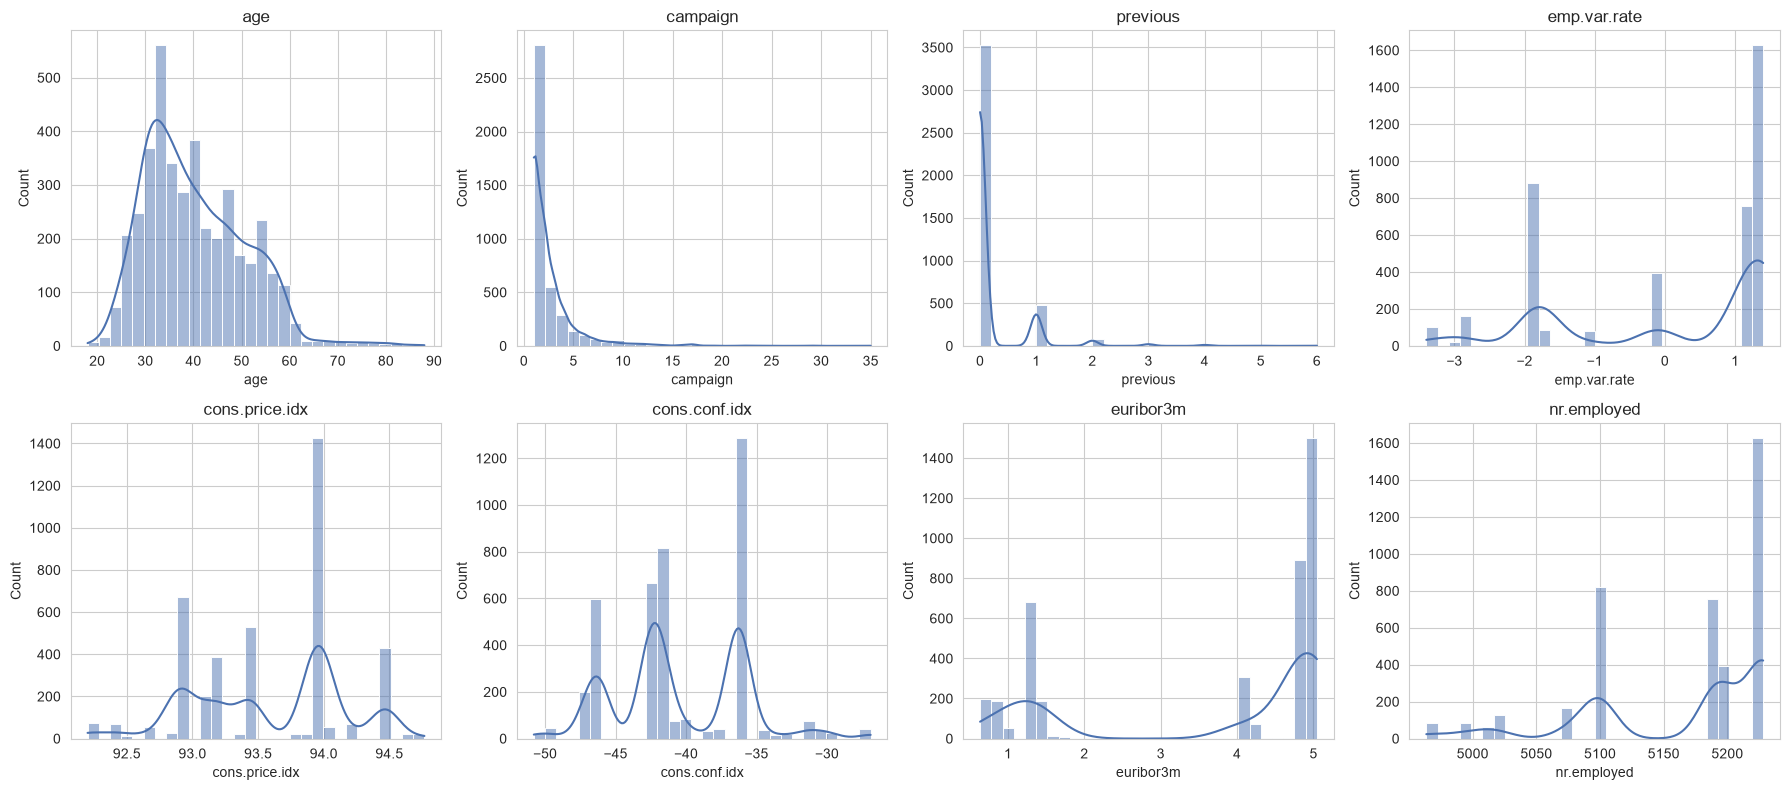

In [27]:
num_cols = ["age", "campaign", "previous", "emp.var.rate",
            "cons.price.idx", "cons.conf.idx", "euribor3m", "nr.employed"]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.flatten(), num_cols):
    sns.histplot(df[col], bins=30, kde=True, ax=ax, color="#4C72B0")
    ax.set_title(col)
plt.tight_layout()
plt.show()

#### 3.3 Numeric features vs. target

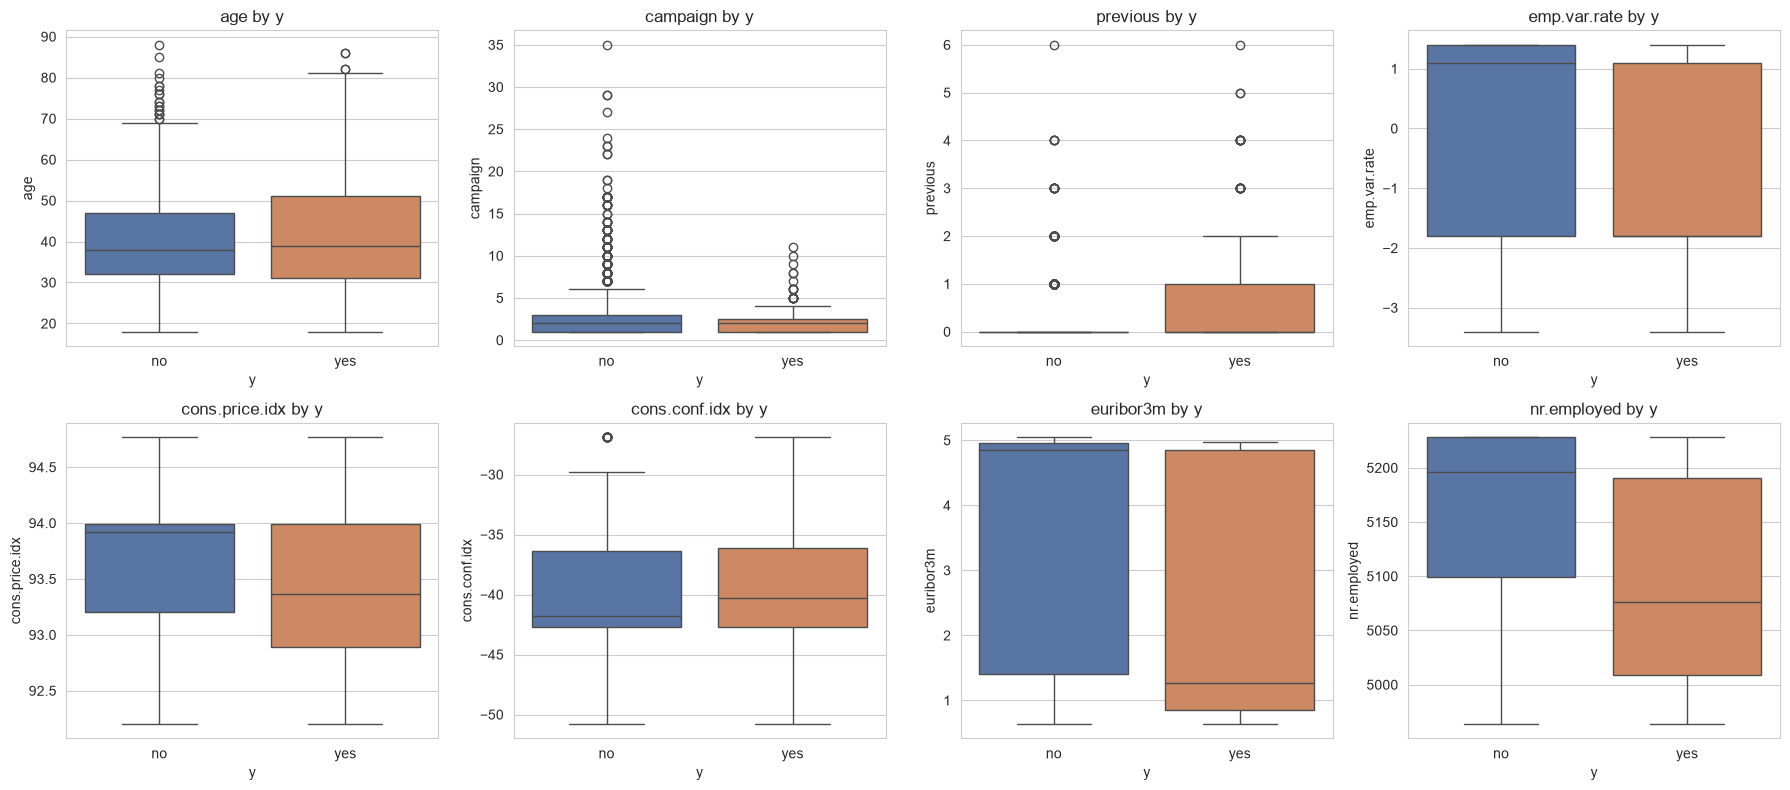

In [28]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.flatten(), num_cols):
    sns.boxplot(x="y", y=col, data=df, ax=ax, palette=["#4C72B0", "#DD8452"])
    ax.set_title(f"{col} by y")
plt.tight_layout()
plt.show()

**Observations:**
- `emp.var.rate`, `euribor3m`, and `nr.employed` tend to be **lower** for clients who
  subscribed — subscriptions rise in weaker macro/interest-rate conditions (people seek
  safer savings vehicles).
- Clients contacted more times in the current campaign (`campaign`) are slightly less
  likely to subscribe — excessive follow-ups may indicate reluctant prospects.
- `previous` (prior contacts) tends to be higher for subscribers, hinting that
  relationship/history matters.

#### 3.4 Categorical features vs. target

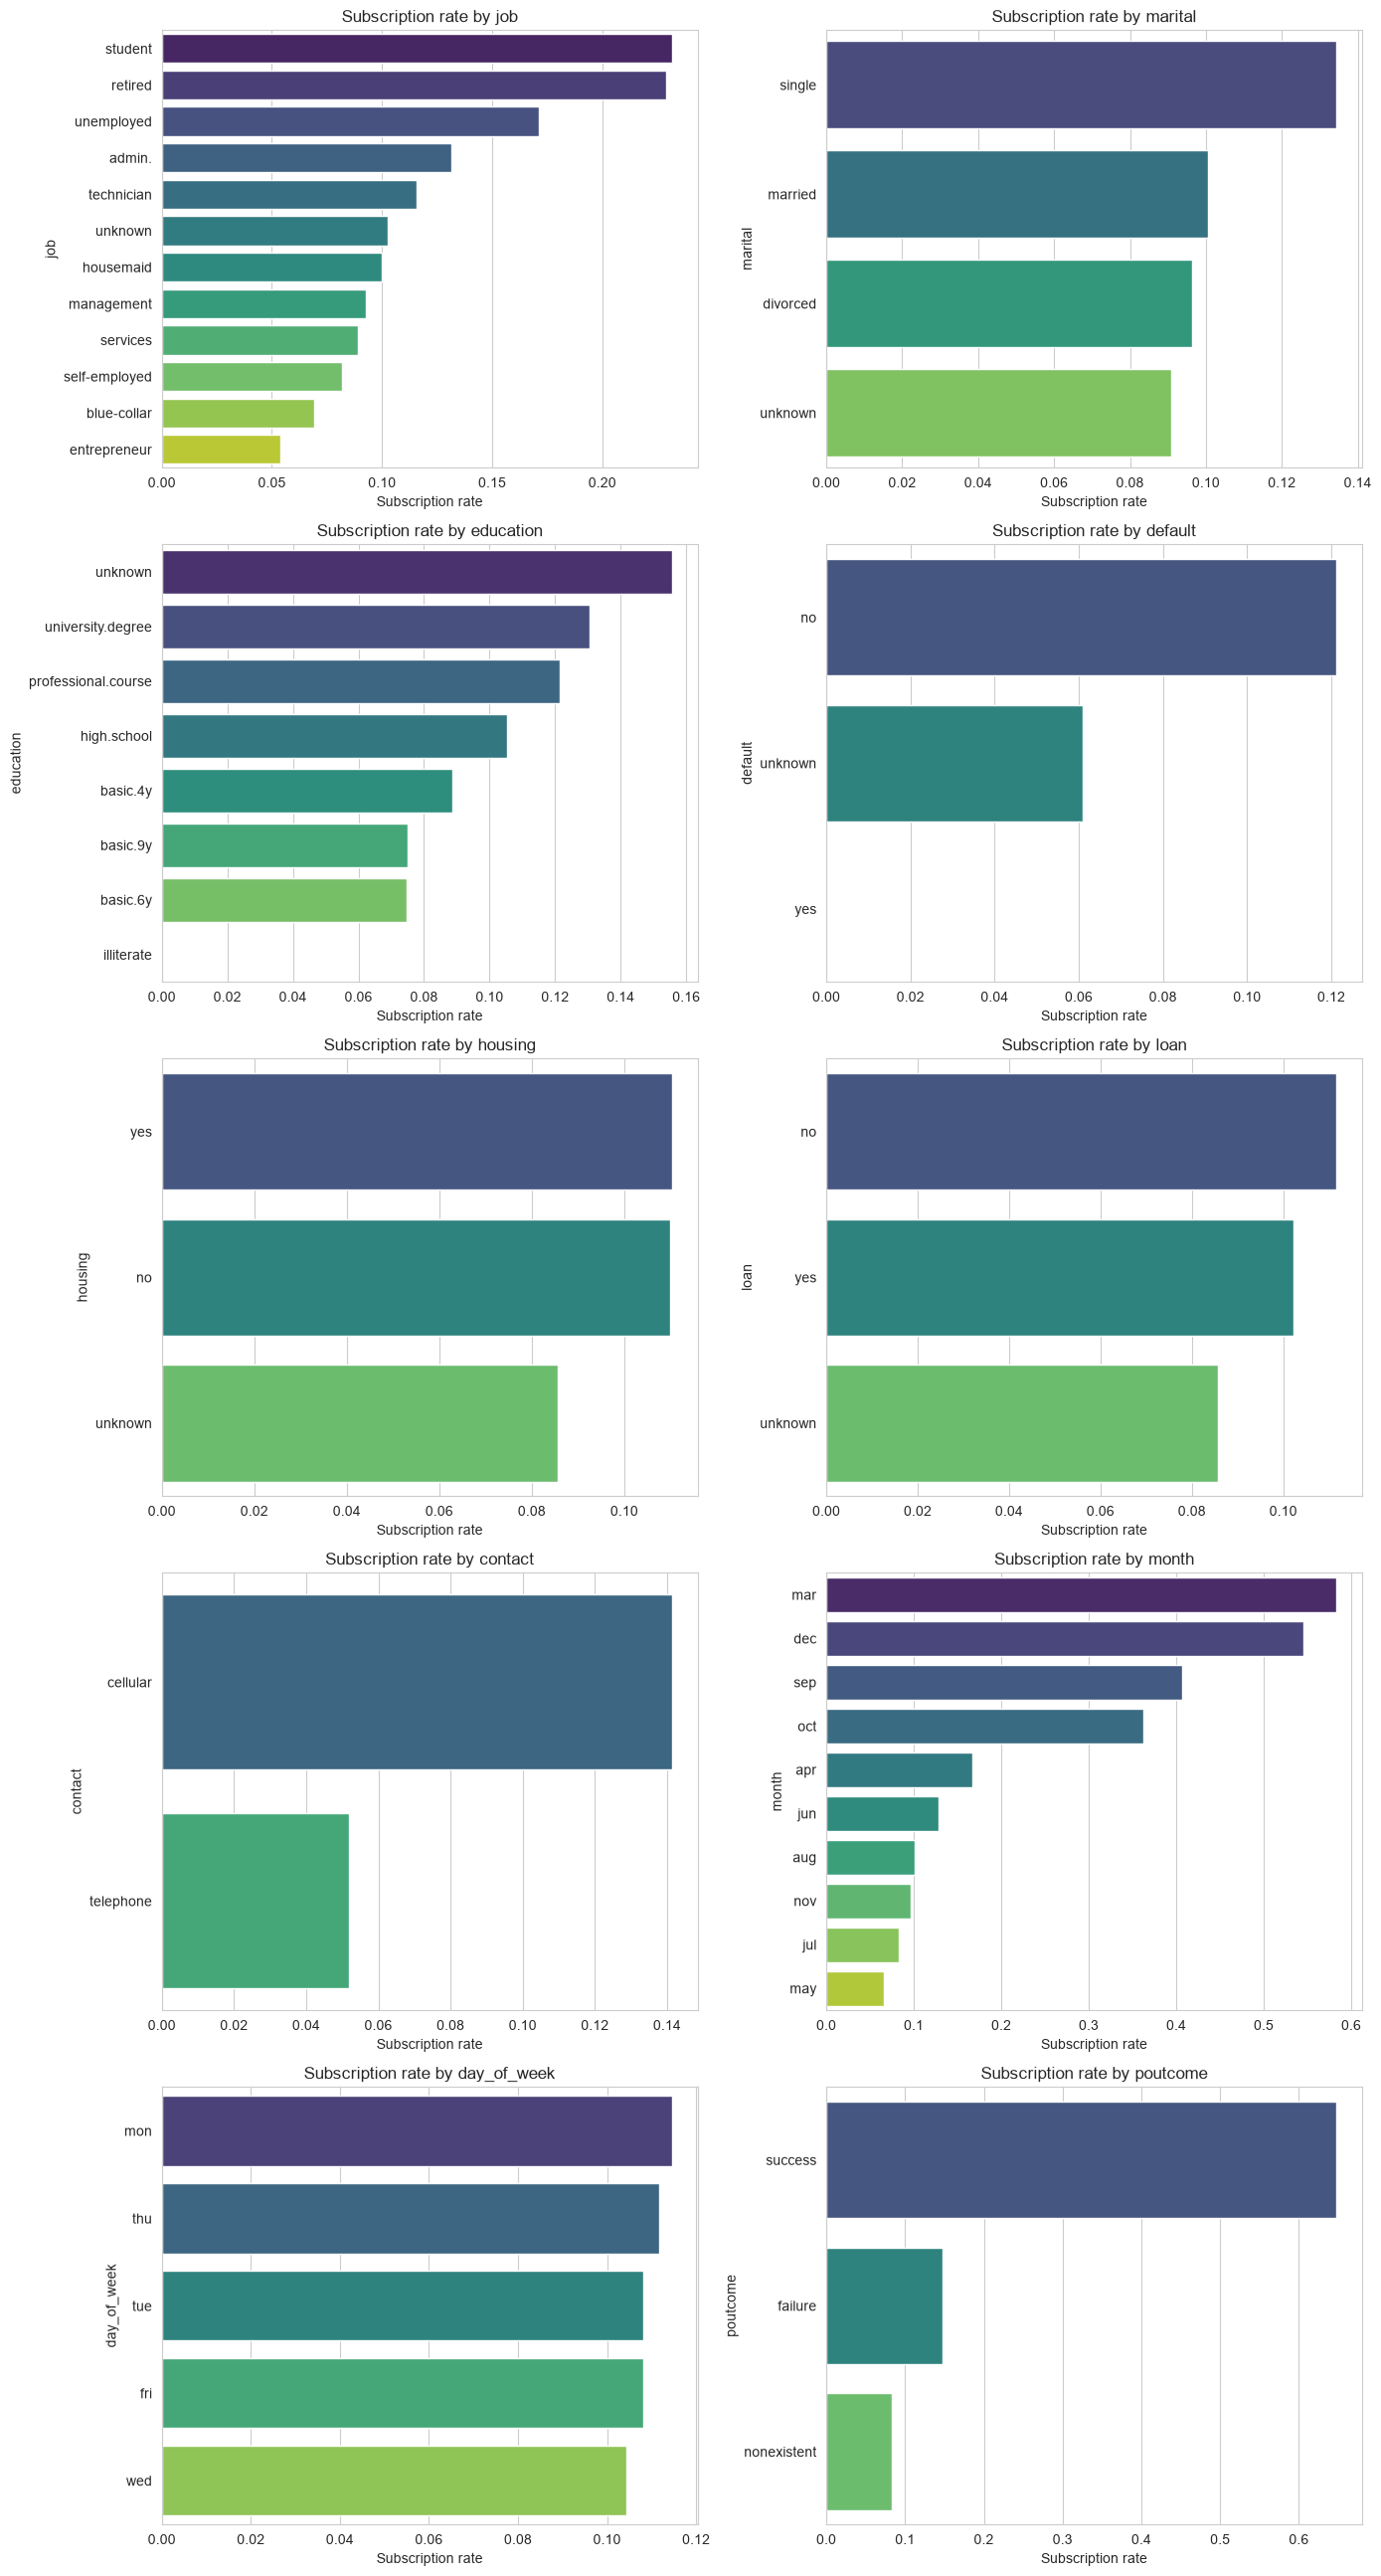

In [29]:
cat_features = ["job", "marital", "education", "default", "housing",
                "loan", "contact", "month", "day_of_week", "poutcome"]

fig, axes = plt.subplots(5, 2, figsize=(14, 26))
for ax, col in zip(axes.flatten(), cat_features):
    rate = df.groupby(col)["y"].apply(lambda s: (s == "yes").mean()).sort_values(ascending=False)
    sns.barplot(x=rate.values, y=rate.index, ax=ax, palette="viridis")
    ax.set_title(f"Subscription rate by {col}")
    ax.set_xlabel("Subscription rate")
plt.tight_layout()
plt.show()

**Observations:**
- `poutcome = success` (client subscribed in a previous campaign) has a **much higher**
  subscription rate — past success is a strong predictor.
- `students` and `retired` clients subscribe at notably higher rates than average.
- `cellular` contact tends to outperform `telephone`.
- Subscription rates vary by `month`, suggesting seasonal campaign effectiveness.


## 4. Feature Engineering & Encoding

- Target `y`: encode `yes` → 1, `no` → 0
- Binary categorical columns (`default`, `housing`, `loan`, `contact`): map to 0/1
- Nominal categorical columns (`job`, `marital`, `education`, `month`, `day_of_week`,
  `poutcome`): one-hot encode
- Numeric columns: standardize

In [31]:
df_model = df.copy()

# Encode target
df_model["y"] = df_model["y"].map({"yes": 1, "no": 0})

# Identify column groups
target = "y"
categorical_cols = ["job", "marital", "education", "default", "housing",
                     "loan", "contact", "month", "day_of_week", "poutcome"]
numeric_cols = ["age", "campaign", "pdays", "previous", "emp.var.rate",
                 "cons.price.idx", "cons.conf.idx", "euribor3m", "nr.employed",
                 "was_previously_contacted"]

df_model = pd.get_dummies(df_model, columns=categorical_cols, drop_first=True)

print("Shape after one-hot encoding:", df_model.shape)
df_model.head()


Shape after one-hot encoding: (4119, 54)


,age,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,was_previously_contacted,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,job_unemployed,job_unknown,marital_married,marital_single,marital_unknown,education_basic.6y,education_basic.9y,education_high.school,education_illiterate,education_professional.course,education_university.degree,education_unknown,default_unknown,default_yes,housing_unknown,housing_yes,loan_unknown,loan_yes,contact_telephone,month_aug,month_dec,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_nonexistent,poutcome_success
0,30,2,999,0,-1.8,92.893,-46.2,1.313,5099.1,0,0,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False
1,39,4,999,0,1.1,93.994,-36.4,4.855,5191.0,0,0,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False
2,25,1,999,0,1.4,94.465,-41.8,4.962,5228.1,0,0,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False,True,True,False
3,38,3,999,0,1.4,94.465,-41.8,4.959,5228.1,0,0,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,True,False,True,False,True,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False
4,47,1,999,0,-0.1,93.200,-42.0,4.191,5195.8,0,0,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,True,False


## 5. Train/Test Split & Scaling

In [32]:
X = df_model.drop(columns=["y"])
y = df_model["y"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("Train positive rate:", y_train.mean().round(3))
print("Test positive rate:", y_test.mean().round(3))

Train shape: (3295, 53)  Test shape: (824, 53)
Train positive rate: 0.11
Test positive rate: 0.109


In [33]:
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

## 6. Train Logistic Regression Model

In [35]:
log_reg = LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42)
log_reg.fit(X_train_scaled, y_train)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",2000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default 

In [36]:
log_reg_plain = LogisticRegression(max_iter=2000, random_state=42)
log_reg_plain.fit(X_train_scaled, y_train)


,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",2000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

## 7. Model Evaluation

In [37]:
def evaluate_model(model, X_test, y_test, name="Model"):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    print(f"===== {name} =====")
    print(f"Accuracy : {accuracy_score(y_test, y_pred):.3f}")
    print(f"Precision: {precision_score(y_test, y_pred):.3f}")
    print(f"Recall   : {recall_score(y_test, y_pred):.3f}")
    print(f"F1-score : {f1_score(y_test, y_pred):.3f}")
    print(f"ROC-AUC  : {roc_auc_score(y_test, y_proba):.3f}")
    print()
    print(classification_report(y_test, y_pred, target_names=["no", "yes"]))
    return y_pred, y_proba

pred_balanced, proba_balanced = evaluate_model(log_reg, X_test_scaled, y_test, "Logistic Regression (balanced)")

===== Logistic Regression (balanced) =====
Accuracy : 0.834
Precision: 0.342
Recall   : 0.567
F1-score : 0.427
ROC-AUC  : 0.762

              precision    recall  f1-score   support

          no       0.94      0.87      0.90       734
         yes       0.34      0.57      0.43        90

    accuracy                           0.83       824
   macro avg       0.64      0.72      0.66       824
weighted avg       0.88      0.83      0.85       824



In [38]:
pred_plain, proba_plain = evaluate_model(log_reg_plain, X_test_scaled, y_test, "Logistic Regression (plain / unweighted)")

===== Logistic Regression (plain / unweighted) =====
Accuracy : 0.902
Precision: 0.696
Recall   : 0.178
F1-score : 0.283
ROC-AUC  : 0.772

              precision    recall  f1-score   support

          no       0.91      0.99      0.95       734
         yes       0.70      0.18      0.28        90

    accuracy                           0.90       824
   macro avg       0.80      0.58      0.62       824
weighted avg       0.88      0.90      0.87       824



### 7.1 Confusion Matrices

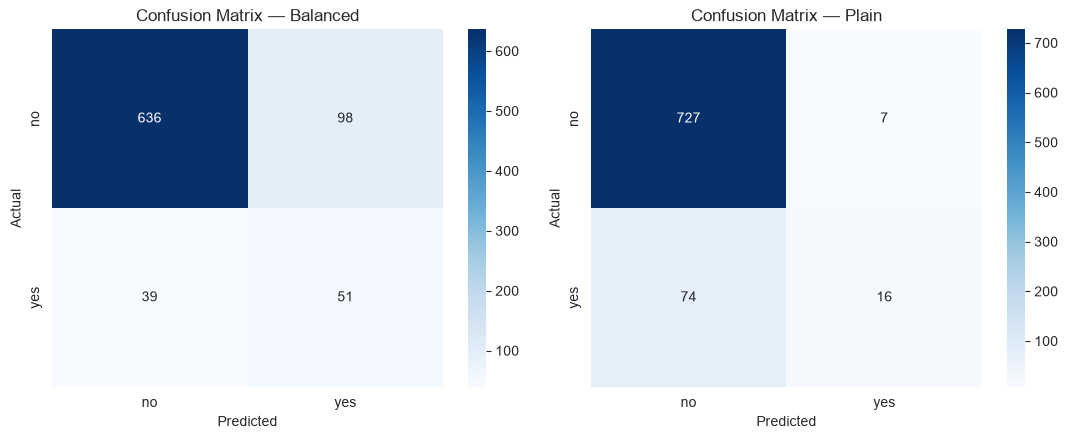

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

for ax, preds, name in zip(axes, [pred_balanced, pred_plain],
                             ["Balanced", "Plain"]):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["no", "yes"], yticklabels=["no", "yes"], ax=ax)
    ax.set_title(f"Confusion Matrix — {name}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()


**Reading the confusion matrix:** the balanced model catches many more true
subscribers (higher recall on the "yes" class) at the cost of more false positives
(lower precision).

### 7.2 ROC Curve

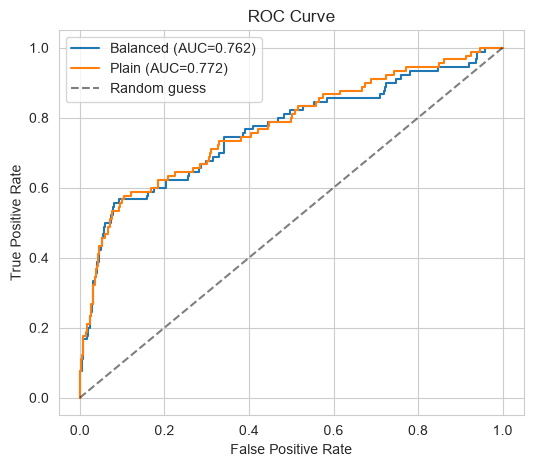

In [41]:
fpr_b, tpr_b, _ = roc_curve(y_test, proba_balanced)
fpr_p, tpr_p, _ = roc_curve(y_test, proba_plain)

plt.figure(figsize=(6,5))
plt.plot(fpr_b, tpr_b, label=f"Balanced (AUC={roc_auc_score(y_test, proba_balanced):.3f})")
plt.plot(fpr_p, tpr_p, label=f"Plain (AUC={roc_auc_score(y_test, proba_plain):.3f})")
plt.plot([0,1],[0,1],'k--', alpha=0.5, label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


**ROC-AUC** is nearly identical between the two models

### 7.3 Precision-Recall Curve

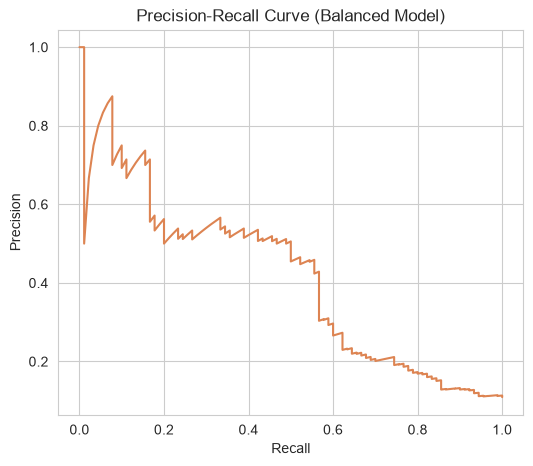

In [42]:
prec_b, rec_b, _ = precision_recall_curve(y_test, proba_balanced)

plt.figure(figsize=(6,5))
plt.plot(rec_b, prec_b, color="#DD8452")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (Balanced Model)")
plt.show()

Since only about 11% of customers subscribe, the dataset is imbalanced. In such cases, the Precision-Recall (PR) curve is more informative than the ROC curve because it focuses on the positive class ("Yes"). It shows the tradeoff between calling more customers to identify more subscribers (high recall, lower precision) and calling fewer, high-confidence customers (high precision, lower recall).